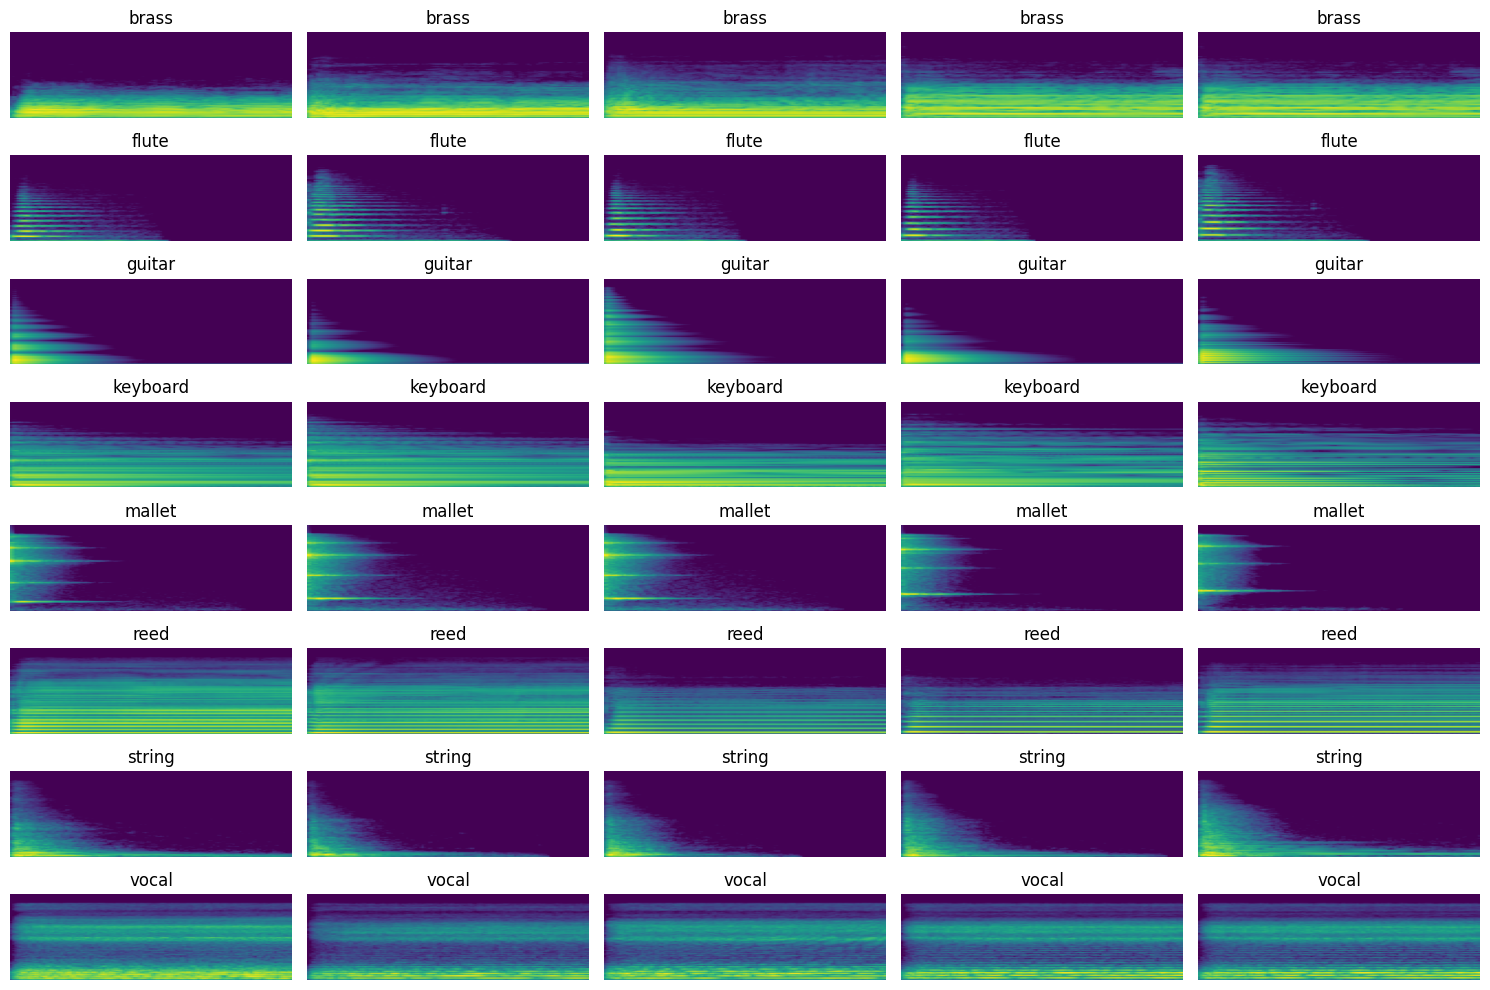

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

X = np.load("/content/drive/MyDrive/InstruNet-AI/Processed/X.npy")
y = np.load("/content/drive/MyDrive/InstruNet-AI/Processed/y.npy")

instrument_names = [
    "brass", "flute", "guitar", "keyboard",
    "mallet", "reed", "string", "vocal"
]

samples_per_class = 5
num_classes = len(instrument_names)

plt.figure(figsize=(15, 10))

plot_index = 1
for label in range(num_classes):
    indices = np.where(y == label)[0][:samples_per_class]

    for idx in indices:
        plt.subplot(num_classes, samples_per_class, plot_index)
        plt.imshow(X[idx], aspect='auto', origin='lower')
        plt.title(instrument_names[label])
        plt.axis('off')
        plot_index += 1

plt.tight_layout()
plt.show()

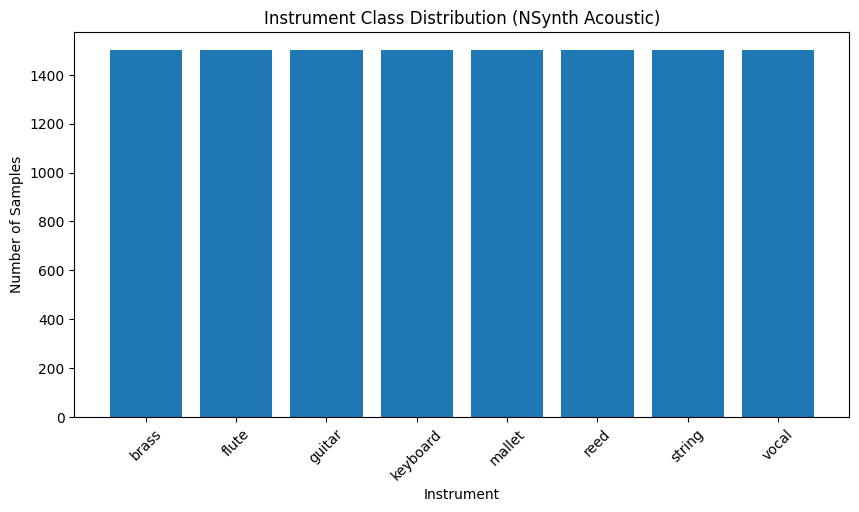

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

unique, counts = np.unique(y, return_counts=True)
labels = [instrument_names[i] for i in unique]

plt.figure(figsize=(10, 5))
plt.bar(labels, counts)
plt.xlabel("Instrument")
plt.ylabel("Number of Samples")
plt.title("Instrument Class Distribution (NSynth Acoustic)")
plt.xticks(rotation=45)
plt.show()


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Load data
X = np.load("/content/drive/MyDrive/InstruNet-AI/Processed/X.npy")
y = np.load("/content/drive/MyDrive/InstruNet-AI/Processed/y.npy")

# Reshape for CNN
X = X[..., np.newaxis]

# One-hot encode labels
y = to_categorical(y)

# Train-validation split (stratified)
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_val.shape)

(9600, 128, 128, 1) (2400, 128, 128, 1)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D,
    BatchNormalization,
    Dense, Dropout, Flatten
)
model = Sequential([

    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128,128,1)),
    MaxPooling2D((2,2)),
    BatchNormalization(),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    BatchNormalization(),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Dropout(0.2),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Dropout(0.2),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.3),

    Dense(8, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(0.0003),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,584,840 (17.49 MB)

 Trainable params: 4,584,648 (17.49 MB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=28,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)


Epoch 1/28
300/300 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.9680 - loss: 0.0849 - val_accuracy: 0.8908 - val_loss: 0.3654
Epoch 2/28
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.9745 - loss: 0.0831 - val_accuracy: 0.9087 - val_loss: 0.2955
Epoch 3/28
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.9735 - loss: 0.0736 - val_accuracy: 0.9142 - val_loss: 0.2858
Epoch 4/28
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.9820 - loss: 0.0563 - val_accuracy: 0.9067 - val_loss: 0.3183
Epoch 5/28
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.9767 - loss: 0.0655 - val_accuracy: 0.9087 - val_loss: 0.3087
Epoch 6/28
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.9854 - loss: 0.0471 - val_accuracy: 0.9158 - val_loss: 0.2838
Epoch 7/28
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.9841 - loss: 0.0490 - val_accuracy: 0.9004 - val_loss: 0.3528
Epoch 8/28
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.9773 - loss: 0.0667 - val_accu

In [ ]:
val_loss, val_acc = model.evaluate(X_val, y_val)
print(f"Optimized Validation Accuracy: {val_acc * 100:.2f}%")

75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9189 - loss: 0.2688
Optimized Validation Accuracy: 91.58%


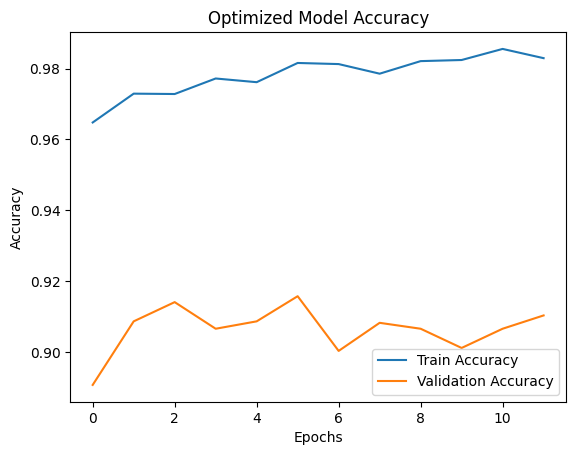

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Optimized Model Accuracy')
plt.show()

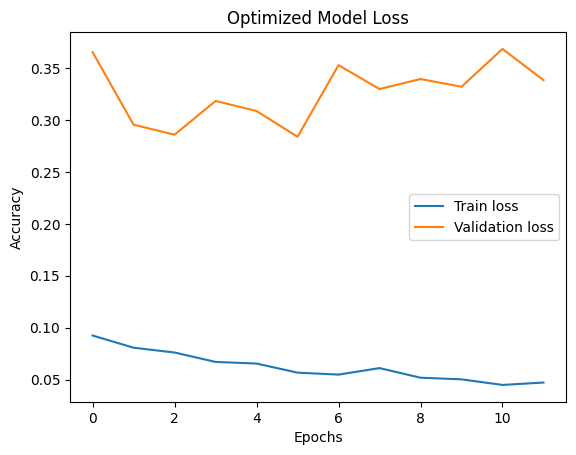

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Optimized Model Loss')
plt.show()

In [ ]:
import numpy as np

y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)


75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [ ]:
import numpy as np

sorted([v for v in globals() if isinstance(globals()[v], np.ndarray)])


['X',
 'X_train',
 'X_val',
 'counts',
 'indices',
 'unique',
 'y',
 'y_pred',
 'y_pred_classes',
 'y_train',
 'y_val']

In [ ]:
import numpy as np

# Convert y_test if it's one-hot encoded
if len(y_val.shape) > 1:
    y_test_classes = np.argmax(y_val, axis=1)
else:
    y_test_classes = y_val

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


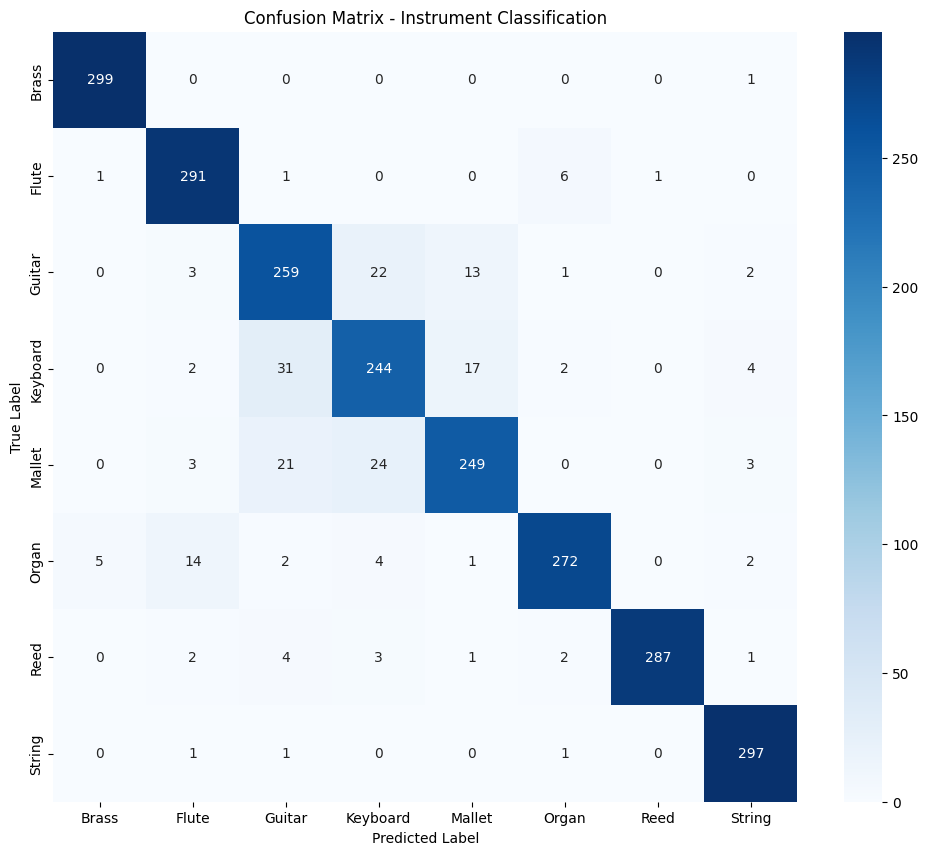

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Class names (IMPORTANT)
class_names = [
    "Brass",
    "Flute",
    "Guitar",
    "Keyboard",
    "Mallet",
    "Organ",
    "Reed",
    "String"
]

# Predict
y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)

# Convert y_test if one-hot
if len(y_val.shape) > 1:
    y_test_classes = np.argmax(y_val, axis=1)
else:
    y_test_classes = y_val

# Confusion Matrix
cm = confusion_matrix(y_test_classes, y_pred_classes)

plt.figure(figsize=(12,10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Instrument Classification")
plt.show()

In [ ]:
print(classification_report(
    y_test_classes,
    y_pred_classes,
    target_names=class_names
))



              precision    recall  f1-score   support

       Brass       0.98      1.00      0.99       300
       Flute       0.92      0.97      0.94       300
      Guitar       0.81      0.86      0.84       300
    Keyboard       0.82      0.81      0.82       300
      Mallet       0.89      0.83      0.86       300
       Organ       0.96      0.91      0.93       300
        Reed       1.00      0.96      0.98       300
      String       0.96      0.99      0.97       300

    accuracy                           0.92      2400
   macro avg       0.92      0.92      0.92      2400
weighted avg       0.92      0.92      0.92      2400



In [ ]:
import numpy as np
import json

BASE_PATH = "/content/drive/MyDrive/InstruNet-AI/Processed"

X = np.load(f"{BASE_PATH}/X.npy")
y = np.load(f"{BASE_PATH}/y.npy")

with open(f"{BASE_PATH}/label_map.json", "r") as f:
    label_map = json.load(f)

# Reverse map for names
class_names = [None] * len(label_map)
for name, idx in label_map.items():
    class_names[idx] = name

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique labels:", np.unique(y))
print("Class names:", class_names)

X shape: (12000, 128, 128)
y shape: (12000,)
Unique labels: [0 1 2 3 4 5 6 7]
Class names: ['brass', 'flute', 'guitar', 'keyboard', 'mallet', 'reed', 'string', 'vocal']


In [ ]:
model.save("model.h5")

with open("label_map.json", "w") as f:
    json.dump(label_map, f)


In [ ]:
import librosa
import numpy as np
import json


In [ ]:
def load_audio(file_path, sr=22050):
    signal, sr = librosa.load(file_path, sr=sr)
    return signal, sr


In [ ]:
def extract_harmonic_features(signal, sr):
    # Separate harmonic and noise components
    harmonic, noise = librosa.effects.hpss(signal)

    # Harmonic-to-Noise Ratio (HNR)
    hnr = np.sum(harmonic**2) / (np.sum(noise**2) + 1e-8)

    # Spectral features
    spectral_centroid = np.mean(librosa.feature.spectral_centroid(y=signal, sr=sr))
    spectral_bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=signal, sr=sr))
    spectral_flatness = np.mean(librosa.feature.spectral_flatness(y=signal))

    # Energy feature
    rms_energy = np.mean(librosa.feature.rms(y=signal))

    return {
        "hnr": float(hnr),
        "spectral_centroid": float(spectral_centroid),
        "spectral_bandwidth": float(spectral_bandwidth),
        "spectral_flatness": float(spectral_flatness),
        "rms_energy": float(rms_energy)
    }


In [ ]:
def determine_instrument_age(features):
    score = 0

    if features["hnr"] > 10:
        score += 1
    if features["spectral_centroid"] > 2000:
        score += 1
    if features["spectral_flatness"] < 0.2:
        score += 1
    if features["rms_energy"] > 0.02:
        score += 1

    if score >= 3:
        return "Young / Healthy Instrument"
    else:
        return "Old / Aged / Degraded Instrument"


In [ ]:
def degradation_explanation(features):
    explanation = []

    if features["hnr"] < 10:
        explanation.append("Reduced harmonic clarity indicates material aging or wear.")

    if features["spectral_flatness"] > 0.25:
        explanation.append("Higher noise components suggest structural degradation.")

    if features["rms_energy"] < 0.02:
        explanation.append("Lower energy output indicates reduced resonance efficiency.")

    if not explanation:
        explanation.append("Strong harmonic structure with minimal degradation detected.")

    return explanation


In [ ]:
def generate_extension_report(audio_path, predicted_instrument, confidence):
    signal, sr = load_audio(audio_path)
    features = extract_harmonic_features(signal, sr)

    age_category = determine_instrument_age(features)
    degradation_notes = degradation_explanation(features)

    report = {
        "predicted_instrument": predicted_instrument,
        "confidence_score": round(confidence, 2),
        "instrument_age_category": age_category,
        "harmonic_analysis": {
            "harmonic_to_noise_ratio": {
                "value": round(features["hnr"], 2),
                "meaning": "Measures harmonic clarity vs noise"
            },
            "spectral_centroid": {
                "value": round(features["spectral_centroid"], 2),
                "meaning": "Represents brightness of the sound"
            },
            "spectral_bandwidth": {
                "value": round(features["spectral_bandwidth"], 2),
                "meaning": "Indicates harmonic spread across frequencies"
            },
            "spectral_flatness": {
                "value": round(features["spectral_flatness"], 3),
                "meaning": "Higher values indicate noisy or degraded sound"
            },
            "rms_energy": {
                "value": round(features["rms_energy"], 4),
                "meaning": "Overall energy and resonance strength"
            }
        },
        "structural_degradation_analysis": degradation_notes
    }

    return report


In [ ]:
audio_file = "/content/drive/MyDrive/nsynth-test.jsonwav/nsynth-test/audio/brass_electronic_025-054-025.wav"

predicted_instrument = "Brass"
confidence_score = 0.92

extension_report = generate_extension_report(
    audio_file,
    predicted_instrument,
    confidence_score
)

with open("instrument_analysis_report.json", "w") as f:
    json.dump(extension_report, f, indent=4)

print(json.dumps(extension_report, indent=4))


{
    "predicted_instrument": "Brass",
    "confidence_score": 0.92,
    "instrument_age_category": "Young / Healthy Instrument",
    "harmonic_analysis": {
        "harmonic_to_noise_ratio": {
            "value": 85.48,
            "meaning": "Measures harmonic clarity vs noise"
        },
        "spectral_centroid": {
            "value": 1163.76,
            "meaning": "Represents brightness of the sound"
        },
        "spectral_bandwidth": {
            "value": 951.68,
            "meaning": "Indicates harmonic spread across frequencies"
        },
        "spectral_flatness": {
            "value": 0.035,
            "meaning": "Higher values indicate noisy or degraded sound"
        },
        "rms_energy": {
            "value": 0.0765,
            "meaning": "Overall energy and resonance strength"
        }
    },
    "structural_degradation_analysis": [
        "Strong harmonic structure with minimal degradation detected."
    ]
}


In [ ]:
from tensorflow.keras.models import load_model
import json

model = load_model("model.h5")


In [ ]:
with open("label_map.json", "r") as f:
    label_map = json.load(f)

# Reverse mapping: index → instrument
index_to_label = {v: k for k, v in label_map.items()}


In [ ]:
import librosa
import numpy as np

def preprocess_audio(audio_path, sr=22050, n_mels=128, max_len=128):
    signal, sr = librosa.load(audio_path, sr=sr)

    mel = librosa.feature.melspectrogram(
        y=signal,
        sr=sr,
        n_mels=n_mels
    )

    mel_db = librosa.power_to_db(mel, ref=np.max)

    # Fix time dimension
    if mel_db.shape[1] < max_len:
        pad = max_len - mel_db.shape[1]
        mel_db = np.pad(mel_db, ((0,0),(0,pad)))
    else:
        mel_db = mel_db[:, :max_len]

    # CNN shape
    mel_db = mel_db[np.newaxis, ..., np.newaxis]

    return mel_db


In [ ]:
def detect_instrument(audio_path):
    X = preprocess_audio(audio_path)

    preds = model.predict(X)
    predicted_index = np.argmax(preds)
    confidence = float(np.max(preds))

    predicted_instrument = index_to_label[predicted_index]

    return predicted_instrument, confidence


In [ ]:
audio_file = "/content/drive/MyDrive/nsynth-test.jsonwav/nsynth-test/audio/guitar_acoustic_016-055-050.wav"

predicted_instrument, confidence_score = detect_instrument(audio_file)

extension_report = generate_extension_report(
    audio_file,
    predicted_instrument,
    confidence_score
)

import json
with open("instrument_analysis_report.json", "w") as f:
    json.dump(extension_report, f, indent=4)

print(json.dumps(extension_report, indent=4))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
{
    "predicted_instrument": "guitar",
    "confidence_score": 0.98,
    "instrument_age_category": "Young / Healthy Instrument",
    "harmonic_analysis": {
        "harmonic_to_noise_ratio": {
            "value": 81.5,
            "meaning": "Measures harmonic clarity vs noise"
        },
        "spectral_centroid": {
            "value": 2464.75,
            "meaning": "Represents brightness of the sound"
        },
        "spectral_bandwidth": {
            "value": 1951.88,
            "meaning": "Indicates harmonic spread across frequencies"
        },
        "spectral_flatness": {
            "value": 0.181,
            "meaning": "Higher values indicate noisy or degraded sound"
        },
        "rms_energy": {
            "value": 0.1462,
            "meaning": "Overall energy and resonance strength"
        }
    },
    "structural_degradation_analysis": [
        "Strong harmonic structure with minimal degradation detected."
    ]
}